# Substitute Impact Analysis

Analyzing goals and assists from substitutes in the Montenegrin First League 2025-26.

In [28]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# Path Configuration
DATA_DIR = Path('..') / 'data'
PROCESSED_DATA_DIR = DATA_DIR / 'processed'
FIGURES_DIR = Path('..') / 'outputs' / 'figures'

# Ensure output directory exists
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("📂 Loading processed data...")

# Load data
player_stats = pd.read_csv(PROCESSED_DATA_DIR / 'match_player_statistics.csv')
teams_meta = pd.read_csv(PROCESSED_DATA_DIR / 'teams_metadata.csv')

# Clean up column names (remove leading/trailing spaces)
teams_meta.columns = teams_meta.columns.str.strip()

print(f"✅ Loaded {len(teams_meta)} teams")
print(f"✅ Loaded {len(player_stats)} player match records")

# Filter for substitutes only
substitutes = player_stats[player_stats['substitute'] == True].copy()

print(f"📊 Found {len(substitutes)} substitute appearances")
print(f"⚽ Total goals from substitutes: {substitutes['goals'].sum():.0f}")
print(f"🎯 Total assists from substitutes: {substitutes['goalAssist'].sum():.0f}")

# Aggregate by team
substitute_impact = substitutes.groupby(['team_id', 'team_name'], as_index=False).agg(
    Goals=('goals', 'sum'),
    Assists=('goalAssist', 'sum')
)

# Merge with teams_meta to get short names
substitute_impact = substitute_impact.merge(teams_meta[['team_id', 'short_name']], on='team_id', how='left')

# Calculate total contributions
substitute_impact['Total'] = substitute_impact['Goals'] + substitute_impact['Assists']

# Sort by total contributions (ascending for horizontal bar chart)
substitute_impact = substitute_impact.sort_values('Total', ascending=True)

📂 Loading processed data...
✅ Loaded 10 teams
✅ Loaded 3782 player match records



✅ Saved alternative visualization to: ..\outputs\figures\substitute_impact.png


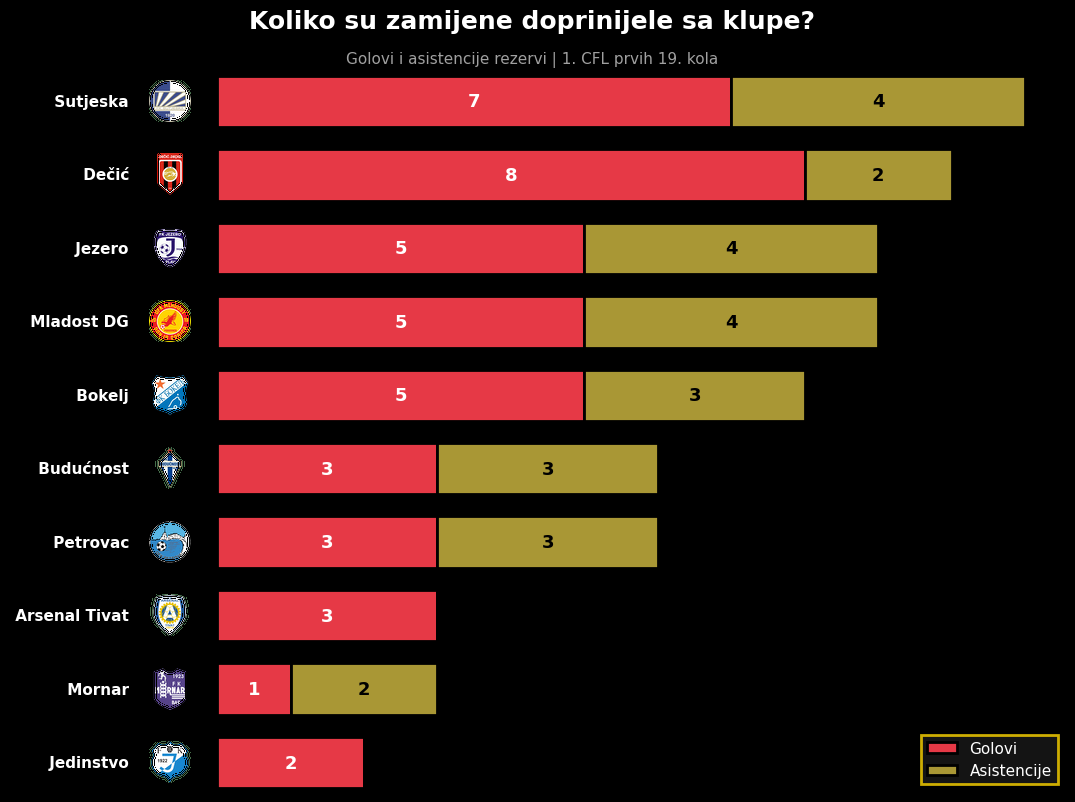

In [45]:
# Alternative rendering without extra vertical padding
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(BG_COLOR_DARK)
ax.set_facecolor(BG_COLOR_DARK)

# Reuse ordering from the earlier aggregation
y_positions = np.arange(len(substitute_impact))
BAR_START_X = 0.65
LOGO_X_CENTER = 0
TEXT_X_END = -0.55

goals_bars = ax.barh(
    y_positions,
    substitute_impact['Goals'],
    height=0.7,
    left=BAR_START_X,
    color=GOAL_COLOR_DARK,
    label='Golovi',
    edgecolor=BG_COLOR_DARK,
    linewidth=2
 )
assists_bars = ax.barh(
    y_positions,
    substitute_impact['Assists'],
    height=0.7,
    left=BAR_START_X + substitute_impact['Goals'],
    color=ASSIST_COLOR_GOLD,
    label='Asistencije',
    edgecolor=BG_COLOR_DARK,
    linewidth=2
 )

for y_idx, (_, row) in enumerate(substitute_impact.iterrows()):
    if row['Goals'] > 0:
        ax.text(
            BAR_START_X + row['Goals'] / 2,
            y_idx,
            f"{int(row['Goals'])}",
            ha='center',
            va='center',
            fontsize=13,
            fontweight='bold',
            color='white'
        )
    if row['Assists'] > 0:
        ax.text(
            BAR_START_X + row['Goals'] + row['Assists'] / 2,
            y_idx,
            f"{int(row['Assists'])}",
            ha='center',
            va='center',
            fontsize=13,
            fontweight='bold',
            color='black'
        )

TEAM_LOGOS_DIR = PROCESSED_DATA_DIR / 'team_logos'
for y_idx, (_, row) in enumerate(substitute_impact.iterrows()):
    logo_path = TEAM_LOGOS_DIR / f"{row['team_id']}.png"
    if not logo_path.exists():
        continue
    try:
        logo_img = Image.open(logo_path).convert('RGBA')
        ax.imshow(
            logo_img,
            extent=[LOGO_X_CENTER - 0.28, LOGO_X_CENTER + 0.28, y_idx - 0.28, y_idx + 0.28],
            aspect='equal',
            zorder=10,
            interpolation='lanczos'
        )
    except Exception as exc:
        print(f"Logo load failed for {row['team_id']}: {exc}")

for y_idx, (_, row) in enumerate(substitute_impact.iterrows()):
    label = row['short_name'] if pd.notna(row['short_name']) else row['team_name']
    ax.text(
        TEXT_X_END,
        y_idx,
        label,
        ha='right',
        va='center',
        fontsize=11,
        color=TEXT_COLOR_LIGHT,
        fontweight='600'
    )

ax.set_yticks([])
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlim(-2.0, BAR_START_X + (substitute_impact['Total'].max() * 1.05))
ax.set_ylim(-0.4, len(substitute_impact) - 0.6)

fig.suptitle(
    "Koliko su zamijene doprinijele sa klupe?",
    fontsize=18,
    fontweight='bold',
    color=TEXT_COLOR_LIGHT,
    y=0.97
)
fig.text(
    0.5,
    0.91,
    "Golovi i asistencije rezervi | 1. CFL prvih 19. kola",
    fontsize=11,
    color='#A0A0A0',
    ha='center'
)

fig.subplots_adjust(left=0.06, right=0.96, top=0.9, bottom=0.1)

legend = ax.legend(
    loc='lower right',
    frameon=True,
    fancybox=False,
    fontsize=11,
    edgecolor='#FFD700',
    facecolor='#1a1a1a',
    labelcolor=TEXT_COLOR_LIGHT
 )
legend.get_frame().set_linewidth(2)

output_path = FIGURES_DIR / 'substitute_impact.png'
plt.savefig(output_path, dpi=300, facecolor=BG_COLOR_DARK, bbox_inches='tight')
print(f"\n✅ Saved alternative visualization to: {output_path}")
plt.show()